<a href="https://colab.research.google.com/github/rriyaram/Customer-segmentation-using-RFM-Recency-Frequency-Monetary-Analysis-in-Python/blob/main/Python_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  
  # Customer Segmentation Using RFM (Recency Frequency Monetary) Analysis

**PROBLEM STATEMENT**

 Bussiness has many customers but not all customers are equally valuable
 company wants to :
     

1.   Identify Loyal Customers

2.  Find at Risk customers
3.  Low value Customers


4. Run targeted Marketing Compaing


5. Segment customers based on purchasing Behaviour






**Outcome**

 Analyzed retail sales data to segment customers using RFM, identifying high-value, loyal, and at-risk customers.
Provided actionable insights on sales trends, top products, and marketing strategies to boost revenue and customer retention.



# Dataset Information

**Domain**

  Retail

Source:https://github.com/LegendSeyi/Retail-Data-Analysis

**Dataset Column/features Description:**

1.Transaction ID -unique Transaction  id for each customers for purchasing

2.Date	-Purchased Date

3.Customer ID - unique id to identify customers

4.Gender - sex of customers

5.Age - Customer Age

6.Product Category - Category of Product

7.Quantity - How much purchased Quantity

8.Price per Unit	- Product Price

9.Total Amount - Amount of Total purchase


**Kind of Analysis to be done**

1️⃣ Data Cleaning & Preparation

2️⃣ Descriptive Analysis

3️⃣ Customer RFM Analysis

4️⃣ Customer Segmentation

5️⃣ Trend Analysis

6️⃣ Product Performance Analysis

7️⃣ Visualization

**Data import**

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/rriyaram/Customer-segmentation-using-RFM-Recency-Frequency-Monetary-Analysis-in-Python/refs/heads/main/retail_sales_dataset.csv")
df
df.to_csv("Retail.csv")

In [ ]:
df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [ ]:
df["Date"] = pd.to_datetime(df["Date"]) #convert to date datatype

In [ ]:
df.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


**Descriptive Statistics**

In [ ]:
df.describe(include='all')

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,NaN,1000,2,NaN,3,NaN,NaN,NaN
top,NaN,NaN,CUST1000,Female,NaN,Clothing,NaN,NaN,NaN
freq,NaN,NaN,1,510,NaN,351,NaN,NaN,NaN
mean,500.500000,2023-07-03 00:25:55.200000256,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,NaN,NaN,64.00000,NaN,4.000000,500.000000,2000.000000


In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


# Data cleaning and Pre -Processing

In [ ]:
df.isnull().mean()*100

,0
Transaction ID,0.0
Date,0.0
Customer ID,0.0
Gender,0.0
Age,0.0
Product Category,0.0
Quantity,0.0
Price per Unit,0.0
Total Amount,0.0


**Insights**

 There is no null values in this data set

#Duplicate Handling

In [ ]:
df.duplicated().sum()

np.int64(0)

**Insights**

 There is no duplicate values all are unique

In [ ]:
df.drop_duplicates()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


#Data Formatting

In [ ]:
df['Gender'].value_counts(dropna=False)

,count
Gender,
Female,510
Male,490


In [ ]:
df['Product Category'].value_counts(dropna=False)

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [ ]:
df[['Age','Price per Unit','Quantity','Total Amount']].describe()

,Age,Price per Unit,Quantity,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,179.890000,2.514000,456.000000
std,13.68143,189.681356,1.132734,559.997632
min,18.00000,25.000000,1.000000,25.000000
25%,29.00000,30.000000,1.000000,60.000000
50%,42.00000,50.000000,3.000000,135.000000
75%,53.00000,300.000000,4.000000,900.000000
max,64.00000,500.000000,4.000000,2000.000000


**INSIGHTS**

 Descriptive statistics for numerical column


Rename column for better understanding

In [ ]:
df.rename(columns={'Date': 'Invoice Date'}, inplace=True)

# Outlier Detection & Treatment

🔍 Using IQR Method

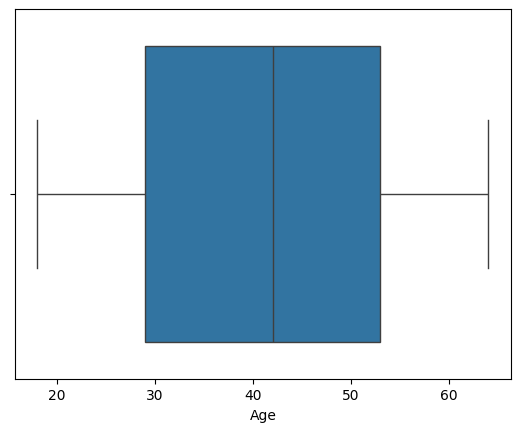

In [ ]:
sns.boxplot(x=df['Age'])
plt.show()

 **INSIGHTS**

There is no outliers

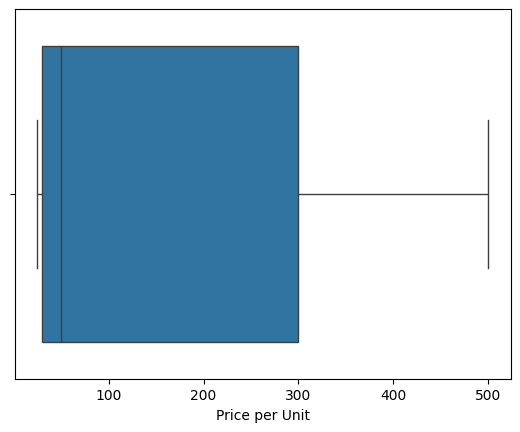

In [ ]:
sns.boxplot(x=df['Price per Unit'])
plt.show()

**INSIGHTS**

There is no outliers

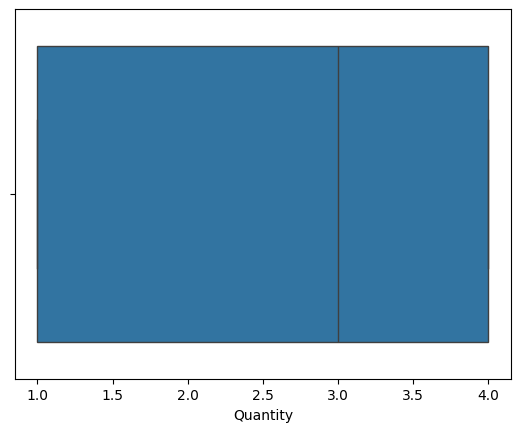

In [ ]:
sns.boxplot(x=df['Quantity'])
plt.show()

**INSIGHTS**

There is no outliers

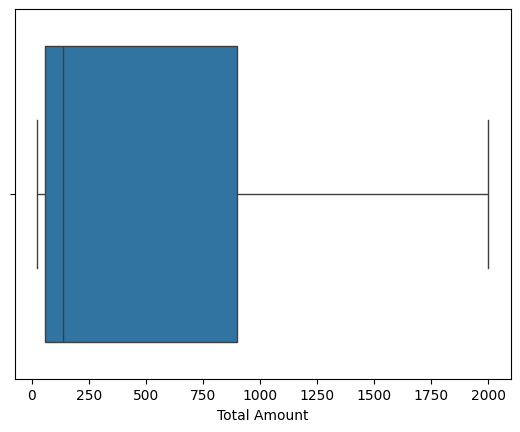

In [ ]:
sns.boxplot(x=df['Total Amount'])
plt.show()

**Insights**

There is no such outliers are occured.But price Per unit,Total amount column is right skewed

#Detect Skewness

In [ ]:
df.skew(numeric_only=True)

,0
Transaction ID,0.000000
Age,-0.048812
Quantity,-0.014036
Price per Unit,0.736308
Total Amount,1.376128


**Insights**

Age,Quantity is almost symmetric no need to be treated but price per unit,Total Amount is moderate to highly Right Skewed.So That should be Treated

#Techniques to handle skewness (Log Transformation)

In [ ]:
df['Price Per unit'] = np.log(df['Price per Unit'])


In [ ]:
df['Total Amount'] = np.log(df['Total Amount'])


#Re-check skewness

In [ ]:
df['Price Per unit'].skew()

np.float64(0.37349123485695046)

In [ ]:
df['Total Amount'].skew()

np.float64(0.24993214153836657)

#Detect Kurtosis

In [ ]:
df['Transaction ID'].kurt()

np.float64(-1.2)

In [ ]:
df['Age'].kurt()

np.float64(-1.2012119166145285)

In [ ]:
df['Quantity'].kurt()

np.float64(-1.392867495407096)

In [ ]:
df['Price Per unit'].kurt()

np.float64(-1.6701537761681453)

In [ ]:
df['Total Amount'].kurt()

np.float64(-1.268618339011523)

**Insights**

Most of your variables are platykurtic.

Only Total Amount shows moderate leptokurtosis.

None are extremely high ( > 3), so there is no severe heavy-tailed behavior.

#Skewness and Kurtosis Recheck

In [ ]:
import scipy.stats as stats

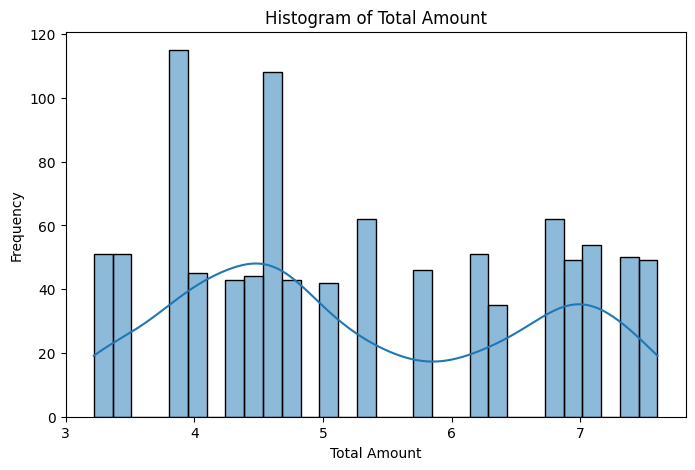

Skewness: 0.24955708700903725
Kurtosis: -1.2682781273046269


In [ ]:
column = 'Total Amount'
plt.figure(figsize=(8,5))
sns.histplot(df[column], kde=True, bins=30)
plt.title(f'Histogram of {column}')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.show()
# Print skewness and kurtosis values
print("Skewness:", stats.skew(df[column], nan_policy='omit'))
print("Kurtosis:", stats.kurtosis(df[column], nan_policy='omit'))

From this histogram:

✔ Distribution is reasonably well-behaved
✔ No extreme outliers visible
✔ No severe skewness
✔ No extreme heavy tails

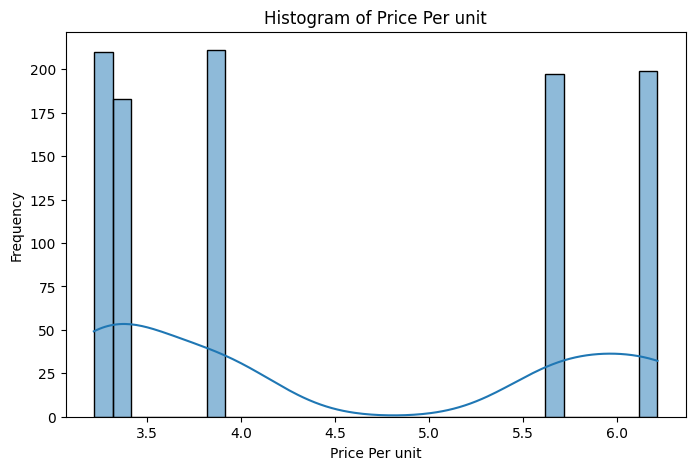

Skewness: 0.37293076440910944
Kurtosis: -1.6678086960186578


In [ ]:
column = 'Price Per unit'
plt.figure(figsize=(8,5))
sns.histplot(df[column], kde=True, bins=30)
plt.title(f'Histogram of {column}')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.show()
# Print skewness and kurtosis values
print("Skewness:", stats.skew(df[column], nan_policy='omit'))
print("Kurtosis:", stats.kurtosis(df[column], nan_policy='omit'))

** Insights **

The price per unit shows a multi-modal distribution, with clear clusters around 3.3–3.5, 3.9–4.0, and 5.6–6.1, indicating distinct pricing tiers and minimal mid-range pricing.

# RFM (Recency Frequency Monetary) Calculation

Objective:

Segment customers based on how recently, how often, and how much they purchase.

To calculate Recency

In [ ]:
snapshot_date = df["Invoice Date"].max() + timedelta(days=1)

Calculate RFM Metrics

In [ ]:
rfm = df.groupby("Customer ID").agg({"Invoice Date": lambda x: (snapshot_date - x.max()).days,  # Recency
    "Transaction ID": "count",                                     # Frequency
    "Total Amount": "sum"                                      # Monetary
}).reset_index()

In [ ]:
rfm.columns = ["Customer ID", "Recency", "Frequency", "Monetary"]   # Rename Column

**Check RFM Distributions (Visual Step)**

 Purpose:
Understand spread before scoring.

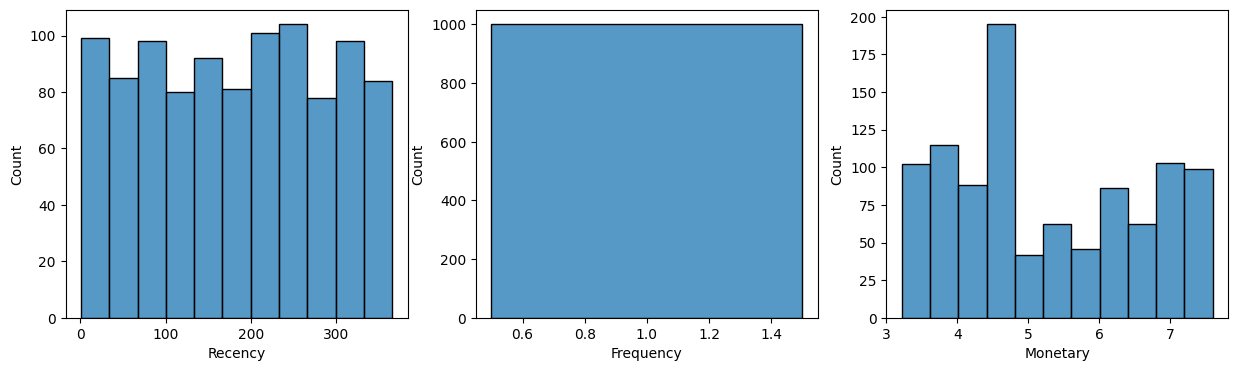

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm["Recency"], ax=axes[0])
sns.histplot(rfm["Frequency"], ax=axes[1])
sns.histplot(rfm["Monetary"], ax=axes[2])
plt.show()

**Insights**

1️⃣ Recency Histogram (Left Plot)

What it shows:

Distribution of days since customers’ last purchase

X-axis: Recency (days)

Y-axis: Number of customers

Interpretation:

Customers on the left bought recently → more engaged

Customers on the right haven’t purchased for a long time → at risk / inactive

Business meaning:
 Many customers have not purchased recently, so re-engagement campaigns may be needed.

2️⃣ Frequency Histogram (Middle Plot)

What it shows:

How often customers make purchases

What we see here:

Almost all values are around 1

Interpretation:

Most customers made only one purchase

Very few repeat customers

Business meaning:
 This is a low repeat-purchase business → focus on loyalty programs and repeat incentives.

3️⃣ Monetary Histogram (Right Plot)

What it shows:

Distribution of total money spent by customers

Interpretation:

Most customers spend in a moderate range

Some customers spend significantly more (right tail)

Business meaning:
 A small group of customers contributes higher revenue → these are potential high-value customers.

# Create RFM Scores

In [ ]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4,labels=[1,2,3,4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"],4,labels=[1,2,3,4])
rfm[["R_Score","F_Score","M_Score"]] = rfm[["R_Score","F_Score","M_Score"]].astype(int)


Create RFM Score & Segment Code

In [ ]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

Create Customer Segments

Segment Analysis (Insights)

In [ ]:
def segment_customer(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Champions"
    elif row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "Loyal Customers"
    elif row["R_Score"] >= 3:
        return "Potential Loyalist"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"
    else:
        return "Lost Customers"
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

Customers per segment

In [ ]:
rfm["Segment"].value_counts()

,count
Segment,
Potential Loyalist,336
Lost Customers,264
Loyal Customers,209
At Risk,122
Champions,69


Revenue Per segment

In [ ]:
rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

,Monetary
Segment,
Potential Loyalist,1679.015571
Lost Customers,1410.656723
Loyal Customers,1341.001549
At Risk,499.507505
Champions,351.786453


#Visualize RFM Results

**Segment Distribution**

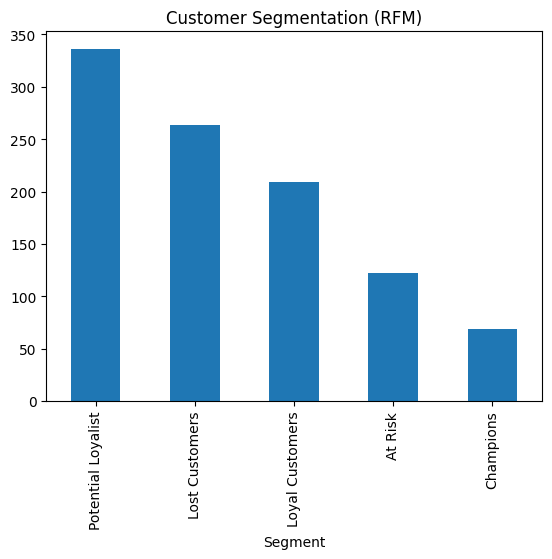

In [ ]:
rfm["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segmentation (RFM)")
plt.show()

**INSIGHTS**

This bar chart clearly shows, based on RFM scores Loyal customers are having high count and also lost customers are next in higher range

**Business Insight**

Focus on converting Potential Loyalists → Champions.

Create re-engagement campaigns for Lost Customers.

Protect and reward your Loyal Customers.

**Monetary by segment**

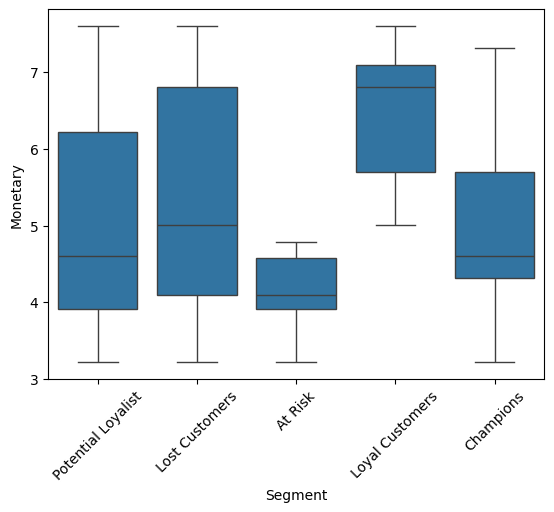

In [ ]:
sns.boxplot(x="Segment", y="Monetary", data=rfm)
plt.xticks(rotation=45)
plt.show()


**INSIGHTS**

Loyal Customers spend the most. champions spend is in consistency

At Risk customers spend the least.

 Lost & Potential Loyalists are mid-level spenders.

 Spending variability exists in most segments.

 Monetary value doesn’t strongly separate the segments.

RFM Score Heatmap

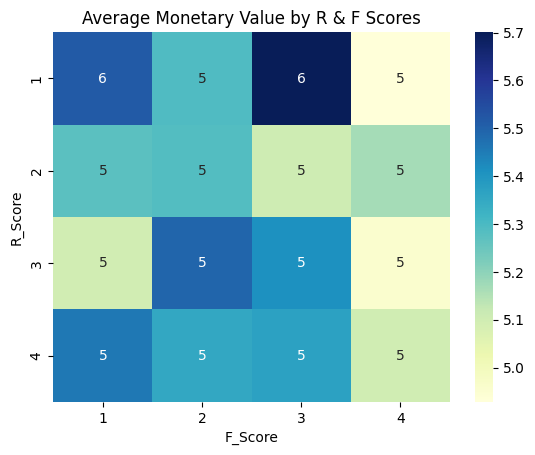

In [ ]:
pivot = rfm.pivot_table(
    index="R_Score",
    columns="F_Score",
    values="Monetary",
    aggfunc="mean"
)
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Monetary Value by R & F Scores")
plt.show()

**INSIGHTS**

Highest average monetary value (~6) occurs at R=1 with F=1 and F=3, indicating top spenders are recent

Most other R–F combinations cluster around ~5, suggesting relatively uniform spending across segments outside the top recent group.

Customer Count vs Revenue (Dual Bar Chart)

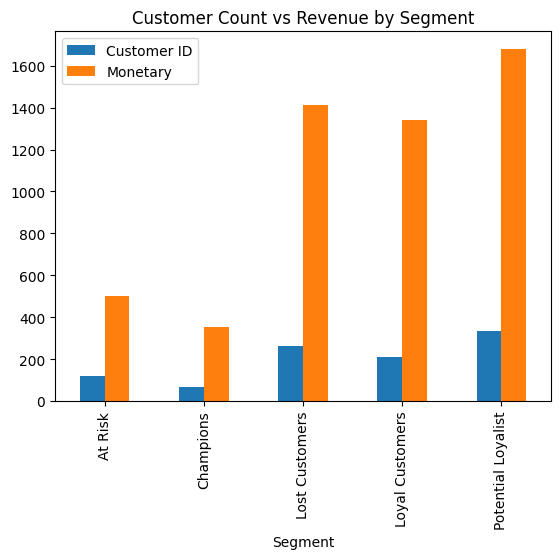

In [ ]:
segment_summary = rfm.groupby("Segment").agg({
    "Customer ID": "count",
    "Monetary": "sum"
})
segment_summary.plot(kind="bar")
plt.title("Customer Count vs Revenue by Segment")
plt.show()

**INSIGHTS**

Potential Loyalist customers give high revenue they are in higher count

champions are in smaller count but give as much as revenue


**Cumulative Revenue Curve**

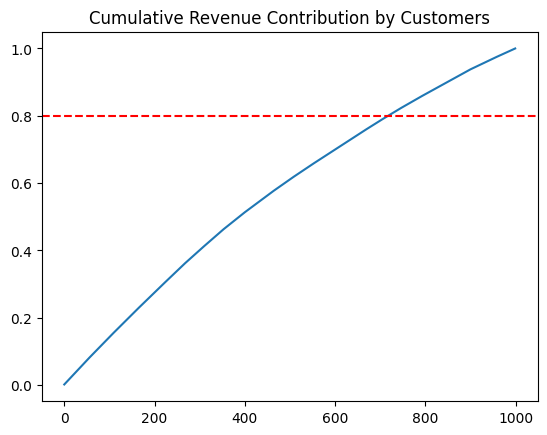

In [ ]:
rfm_sorted = rfm.sort_values("Monetary", ascending=False)
rfm_sorted["CumulativeRevenue"] = rfm_sorted["Monetary"].cumsum()
rfm_sorted["CumulativePercent"] = (
    rfm_sorted["CumulativeRevenue"] / rfm_sorted["Monetary"].sum()
)
plt.plot(rfm_sorted["CumulativePercent"].values)
plt.axhline(0.8, color="red", linestyle="--")
plt.title("Cumulative Revenue Contribution by Customers")
plt.show()

**INSIGHTS**

Revenue is not evenly distributed
The curve rises quickly at the beginning → early customers contribute a large portion of revenue.

80% revenue comes from fewer customers
The blue line crosses the red 80% line before reaching all customers → a smaller group generates most revenue.

Pareto Principle (80/20 rule) likely applies
A minority of customers are high-value customers.

Remaining customers contribute less individually
After crossing 80%, the curve increases slowly → many customers add small amounts.

Business Meaning:

Focus on retaining top customers

Create loyalty programs for high-value group

Improve strategies to increase spending of low-contributing customers

In [ ]:
rfm.to_csv("rfm_output.csv", index=False)

Business Insights & Recommendations

Champions ,Loyal customers generate high frequency,recency  gradual of revenue

At-risk customers need re-engagement

Lost customers have low frequency and monetary value

Give discounts,Subscriptons to retain customers when industry focus sales more than profit


#POWERBI DASHBOARD

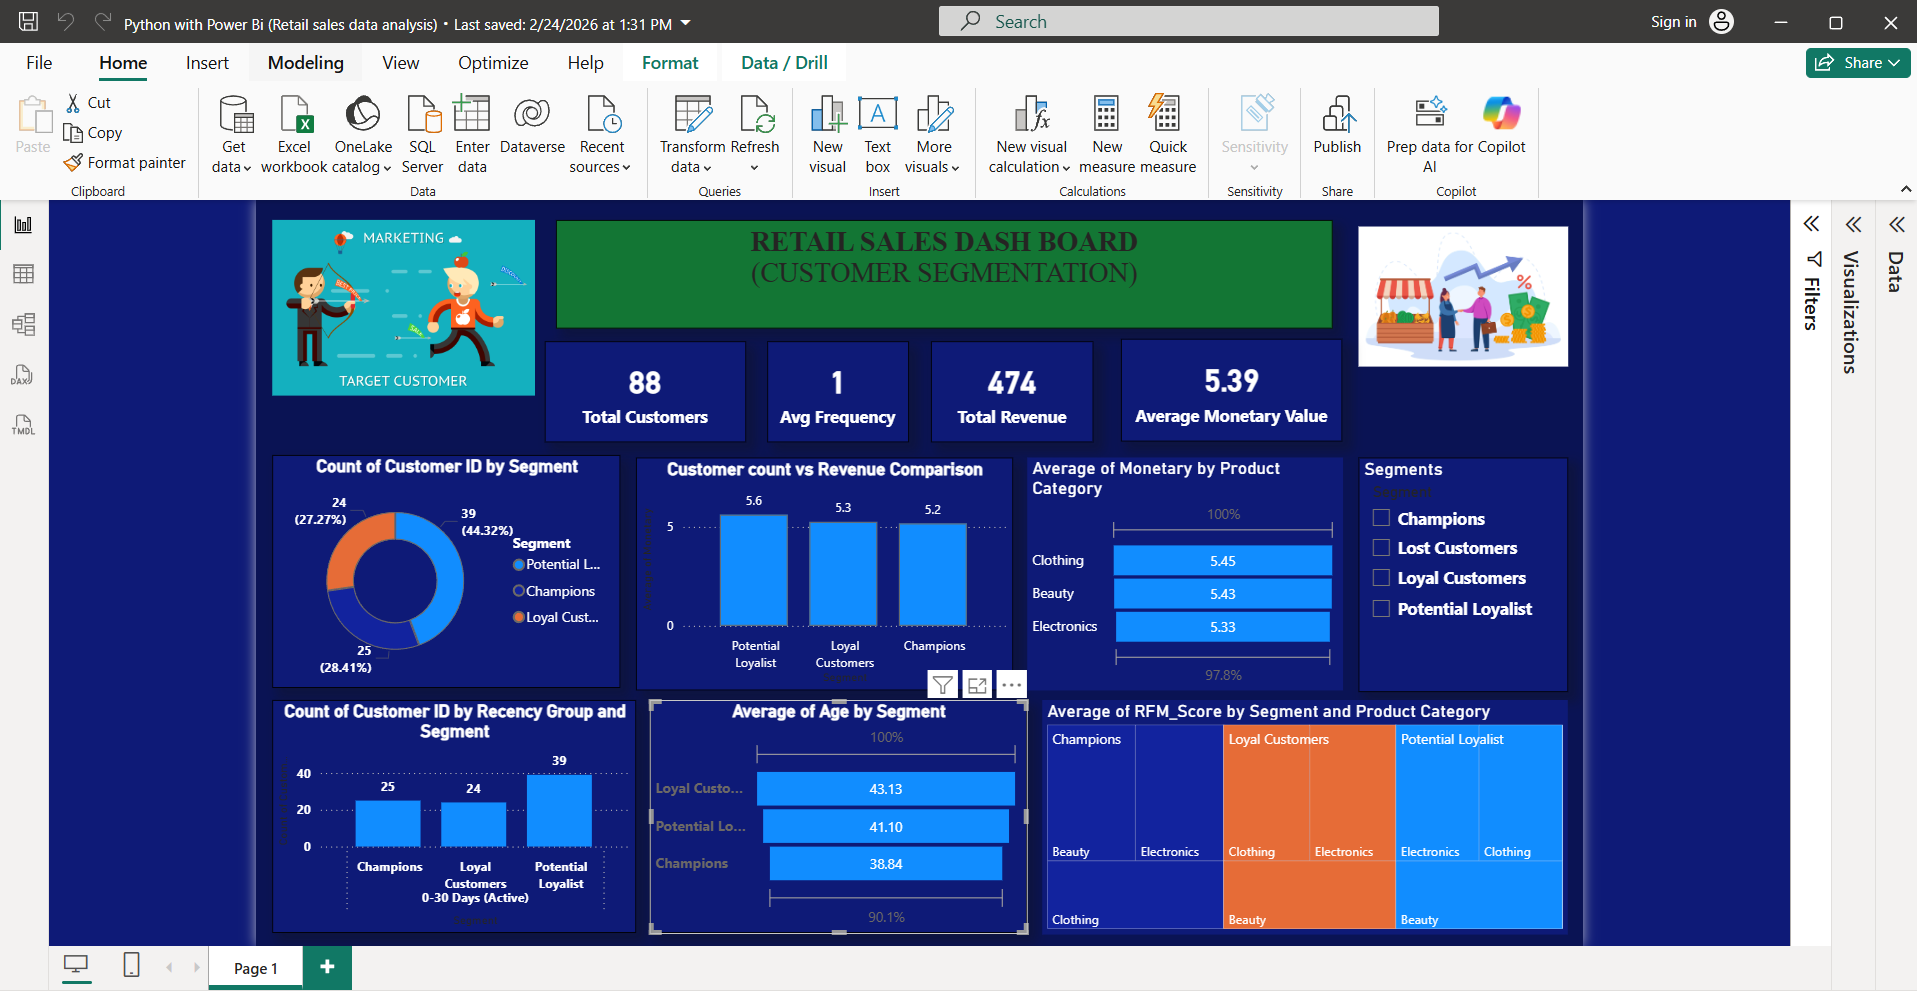

##Analysis and Recommendation

•	Introduce loyalty programs to encourage repeat purchases

•	Provide personalized offers to high-value customers

•	Re-engage inactive customers using targeted campaigns

•	Focus marketing resources on profitable customer segments
